In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df = pd.read_csv(r"data\wine_full.csv")

# Wine Quality Analysis

In [159]:
df.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed.acidity         6497 non-null   float64
 1   volatile.acidity      6497 non-null   float64
 2   citric.acid           6497 non-null   float64
 3   residual.sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free.sulfur.dioxide   6497 non-null   float64
 6   total.sulfur.dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


#### no nulls, also data types seem consistant

In [161]:
df.describe()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [162]:
df.duplicated().sum()

np.int64(1177)

In [163]:
df.nunique()

fixed.acidity           106
volatile.acidity        187
citric.acid              89
residual.sugar          316
chlorides               214
free.sulfur.dioxide     135
total.sulfur.dioxide    276
density                 998
pH                      108
sulphates               111
alcohol                 111
quality                   7
color                     2
dtype: int64

## Q1: What chemical characteristics are most important in predicting the quality of wine?

In [164]:
correlation = df.corr(numeric_only=True)
correlation

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
fixed.acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile.acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric.acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual.sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free.sulfur.dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total.sulfur.dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


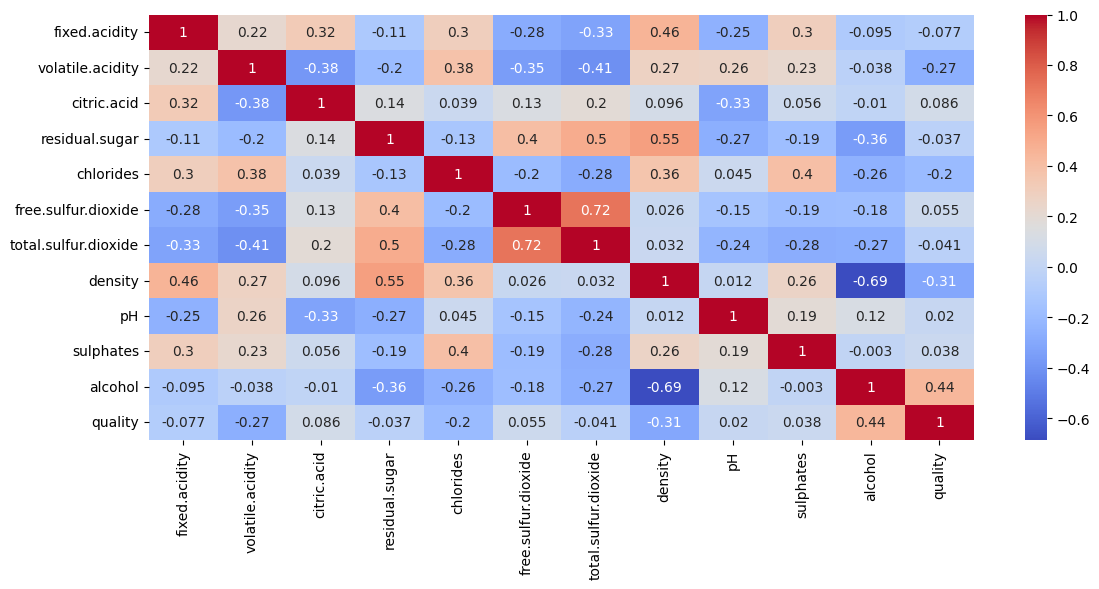

In [165]:
plt.figure(figsize=(12,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.tight_layout()

plt.show()

### Findings
as you can see **alcohol** has the highest correlation with the quality of our wine.
also we have **volatile acidity**, **density** and **chlorides** in the second, third and fourth place.

## Q2: Is a certain type of wine (red or white) associated with higher quality?

In [166]:
color_quality = df.groupby('color',as_index=False)['quality'].mean().sort_values('quality',ascending=True)
color_quality

,color,quality
0,red,5.636023
1,white,5.877909


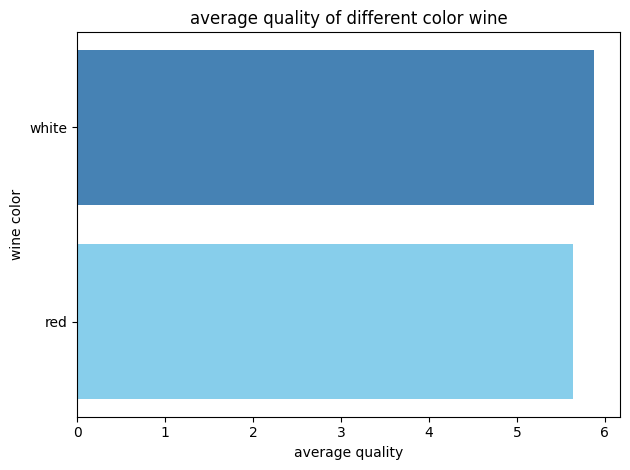

In [167]:
plt.barh(color_quality['color'],color_quality['quality'],color=['skyblue','steelblue'])
plt.title('average quality of different color wine')
plt.xlabel('average quality')
plt.ylabel('wine color')
plt.tight_layout()
plt.show()

### Findings
**white wine** has slightly better average quality than **red wine**

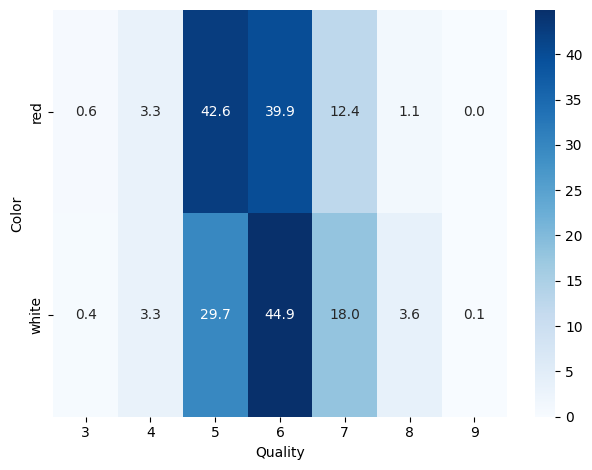

In [168]:
color_quality = pd.crosstab(df['color'],df['quality'],normalize='index') * 100

sns.heatmap(color_quality, annot=True, fmt='.1f', cmap='Blues')

plt.xlabel('Quality')
plt.ylabel('Color')
plt.tight_layout()
plt.show()

### Findings
as you can see most of the **white wine** has the quality of **6** and the **red wine** has the quality of **5**

## Q3: Do wines with higher alcoholic content receive better ratings?

In [169]:
correlation = df['alcohol'].corr(df['quality'])

print(correlation)

0.4443185200076544


### Findings
there is a slight correlation

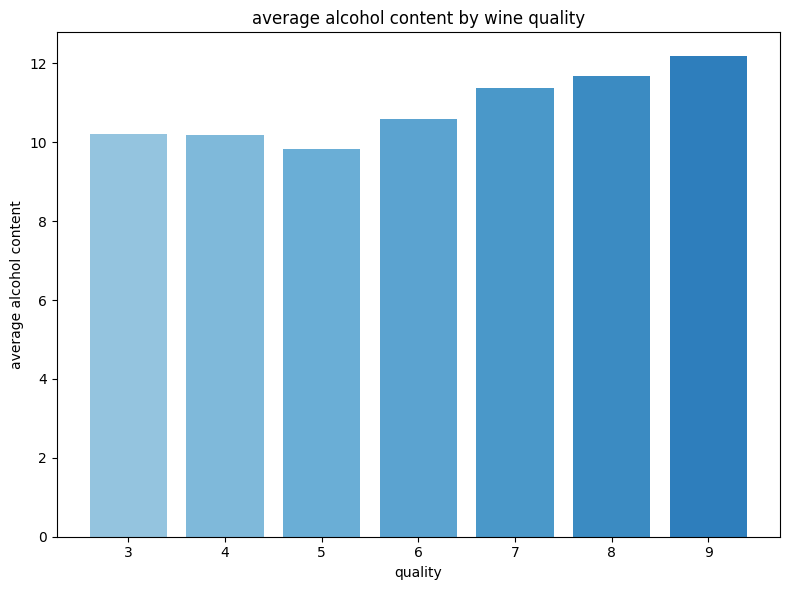

In [170]:
avg_alcohol = df.groupby('quality',as_index=False)['alcohol'].mean()

plt.figure(figsize=(8, 6))

colors = plt.cm.Blues(np.linspace(0.4,0.7,7))

plt.bar(avg_alcohol['quality'], avg_alcohol['alcohol'],color=colors)

plt.xlabel('quality')
plt.ylabel('average alcohol content')
plt.title('average alcohol content by wine quality')

plt.tight_layout()
plt.show()

### Findings
the more the quality the more the **alcohol content**

## Q4: Do sweeter wines (more residual sugar) receive better ratings?

In [171]:
df.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


In [172]:
df['residual.sugar'].corr(df['quality'])

np.float64(-0.03698048458576944)

### Findings
there is no correlation between the two

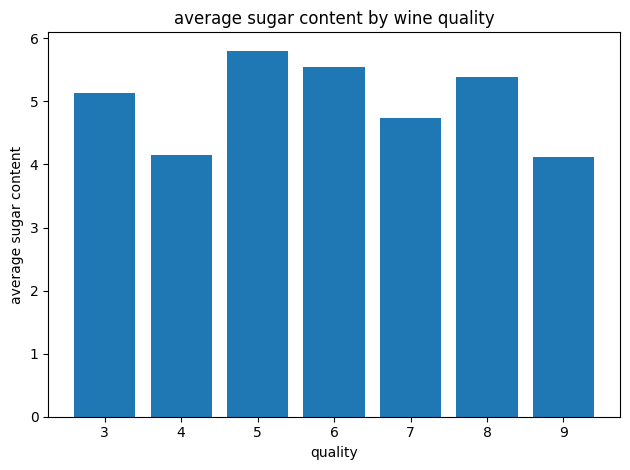

In [173]:
sugar_quality = df.groupby('quality',as_index=False)['residual.sugar'].mean()

plt.bar(sugar_quality['quality'],sugar_quality['residual.sugar'])

plt.xlabel('quality')
plt.ylabel('average sugar content')
plt.title('average sugar content by wine quality')

plt.tight_layout()
plt.show()

### Findings
the **sweetness** of the wine does not effect the rating 

## Q5: What level of acidity (pH) is associated with the highest quality?

In [174]:
def classify_acidity(ph):
    if ph <= 2.9:
        return 'very high'
    elif ph <= 3.2:
        return 'high'
    elif ph <= 3.5:
        return 'moderate'
    else:
        return 'low'

df['acidity_level'] = df['pH'].apply(classify_acidity)


In [175]:
result = df.groupby(['quality','acidity_level']).size().unstack(fill_value=0)
result

acidity_level,high,low,moderate,very high
quality,,,,
3,8,4,15,3
4,103,19,90,4
5,1100,101,904,33
6,1333,122,1328,53
7,488,54,520,17
8,86,9,97,1
9,1,0,4,0


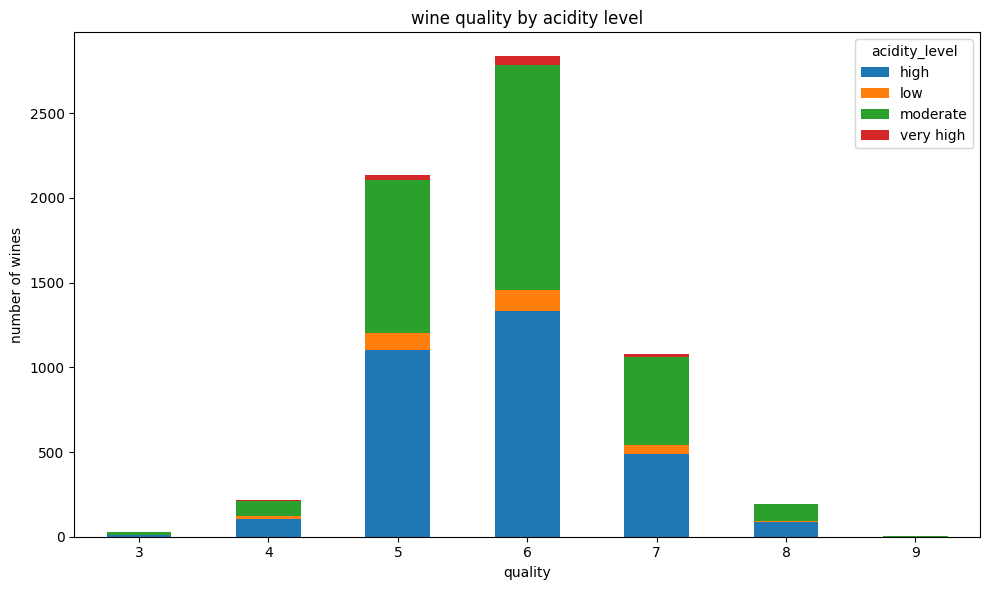

In [176]:
result.plot(kind='bar',stacked=True,figsize=(10, 6))

plt.xlabel('quality')
plt.ylabel('number of wines')
plt.title('wine quality by acidity level')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [177]:
result = pd.crosstab(df['quality'],df['acidity_level'],normalize='index') * 100
result

acidity_level,high,low,moderate,very high
quality,,,,
3,26.666667,13.333333,50.000000,10.000000
4,47.685185,8.796296,41.666667,1.851852
5,51.449953,4.724041,42.282507,1.543499
6,47.002821,4.301834,46.826516,1.868829
7,45.227062,5.004634,48.192771,1.575533
8,44.559585,4.663212,50.259067,0.518135
9,20.000000,0.000000,80.000000,0.000000


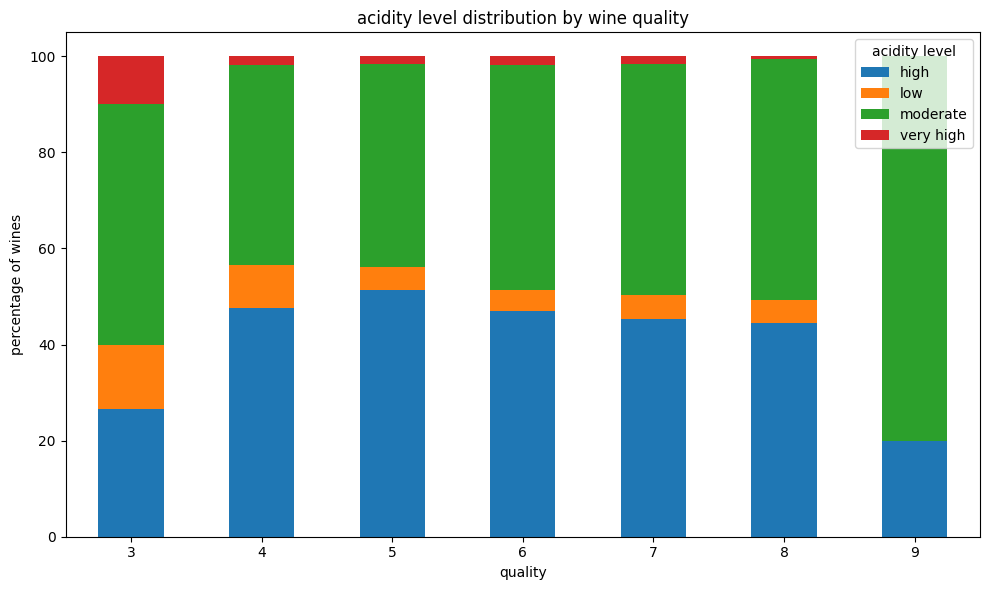

In [178]:
result.plot(kind='bar',stacked=True,figsize=(10, 6))

plt.xlabel('quality')
plt.ylabel('percentage of wines')
plt.title('acidity level distribution by wine quality')

plt.xticks(rotation=0)
plt.legend(title='acidity level')

plt.tight_layout()
plt.show()

### Findings
as you can see the higher the quality goes number of acidity levels of **very high** & **low** goes down

so we end up with **high** and **moderate** acidity levels

### Summary of Findings

- **Alcohol content** shows the strongest relationship with quality (r ≈ 0.44) — higher-alcohol wines tend to score higher.
- **Density** and **volatile acidity** show moderate negative correlations (r ≈ -0.31 and -0.27) — lower density and lower volatile acidity associate with higher-rated wines.
- **Wine color**: white wine has a slightly higher average quality than red, though the difference is modest.
- **Residual sugar** shows no meaningful correlation with quality (r ≈ -0.04) — sweetness does not predict rating.
- **Acidity (pH)**: top-rated wines cluster in the "high" to "moderate" acidity range; very high and low acidity levels become rarer as quality increases.

Overall, alcohol content, density, and volatile acidity are the most useful chemical predictors of wine quality in this dataset, while sugar content appears essentially unrelated.

#### 